# Phase 3 : Modélisation Prédictive

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, GridSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve,
                              precision_recall_curve, fbeta_score)
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/top_features.csv")
df.head()

,age_sysBP,risk_score,age,sysBP,pulse_pressure,prevalentHyp,diaBP,Tension_Hypertension,Tension_Normale,diabetes,male,TenYearCHD
0,4134.0,0,39,106.0,36.0,0,70.0,0,1,0,1,0
1,5566.0,1,46,121.0,40.0,0,81.0,1,0,0,0,0
2,6120.0,2,48,127.5,47.5,0,80.0,1,0,0,1,0
3,9150.0,6,61,150.0,55.0,1,95.0,1,0,0,0,1
4,5980.0,2,46,130.0,46.0,0,84.0,1,0,0,0,0


1. Préparation des données :

* Conversion des colonnes booléennes avant le split.

L'encodage des colonnes booléennes est effectué **avant** la séparation train/test pour s'assurer que `x_train` et `x_test` ont des types cohérents dès le départ.

In [3]:
bool_cols = df.select_dtypes(include="bool").columns.tolist()
for col in bool_cols:
    df[col] = df[col].astype(int)

print(f"Colonnes converties : {bool_cols}")
print(f"Types après conversion :\n{df.dtypes.value_counts()}")

Colonnes converties : []
Types après conversion :
int64      8
float64    4
Name: count, dtype: int64


* Séparation des données en ensemble d'entraînement (70 %) et ensemble de test (30 %).

In [4]:
feature = df.drop("TenYearCHD", axis=1)
target  = df["TenYearCHD"]

x_train, x_test, y_train, y_test = train_test_split(
    feature, target, test_size=0.3, random_state=42, stratify=target
)

print(f"Taille train : {x_train.shape}, test : {x_test.shape}")
print(f"Distribution cible (train) :\n{y_train.value_counts(normalize=True).round(3)}")

Taille train : (2968, 11), test : (1272, 11)
Distribution cible (train) :
TenYearCHD
0    0.848
1    0.152
Name: proportion, dtype: float64


2. Construction des modèles :

* Baseline avec un classifieur naïf.

Avant tout modèle appris, on établit une référence (baseline) avec un `DummyClassifier` qui prédit toujours la classe majoritaire. Tout modèle utile doit dépasser ce niveau.

In [5]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(x_train, y_train)
y_pred_dummy = dummy.predict(x_test)

print("Baseline (DummyClassifier - most_frequent) :")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_dummy):.3f}")
print(f"  Recall   : {recall_score(y_test, y_pred_dummy, zero_division=0):.3f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, dummy.predict_proba(x_test)[:, 1]):.3f}")

Baseline (DummyClassifier - most_frequent) :
  Accuracy : 0.848
  Recall   : 0.000
  ROC-AUC  : 0.500


* Définition des pipelines de modélisation.

Chaque modèle est encapsulé dans un `Pipeline` scikit-learn qui intègre la normalisation. Cette approche garantit qu'il n'y a aucune fuite d'information entre le train et le test : le scaler est fitté uniquement sur les données d'entraînement à chaque fold de validation croisée.

La normalisation est incluse pour la `LogisticRegression` (sensible à l'échelle). Pour les modèles à base d'arbres (`RandomForest`, `GradientBoosting`, `HistGradientBoosting`), elle est également incluse par cohérence mais n'affecte pas leurs performances.

In [6]:
models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]),
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            max_depth=8,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "GradientBoosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            random_state=42
        ))
    ]),
    "HistGradientBoosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            max_depth=5,
            class_weight="balanced",
            random_state=42
        ))
    ]),
}

print(f"{len(models)} pipelines configurés")

4 pipelines configurés


* Entraînement et évaluation initiale sur le jeu de test.

In [7]:
results = []

for name, model in models.items():
    print("=" * 50)
    print(f"Entraînement : {name}")

    model.fit(x_train, y_train)

    y_pred  = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1]

    results.append({
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_test, y_pred), 3),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 3),
        "Recall"   : round(recall_score(y_test, y_pred), 3),
        "F1-Score" : round(f1_score(y_test, y_pred), 3),
        "ROC-AUC"  : round(roc_auc_score(y_test, y_proba), 3),
    })

    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results).set_index("Model")
print("\nComparaison des modèles :")
print(results_df)

Entraînement : LogisticRegression
              precision    recall  f1-score   support

           0       0.91      0.67      0.77      1079
           1       0.26      0.63      0.36       193

    accuracy                           0.67      1272
   macro avg       0.58      0.65      0.57      1272
weighted avg       0.81      0.67      0.71      1272

Entraînement : RandomForest
              precision    recall  f1-score   support

           0       0.89      0.77      0.82      1079
           1       0.26      0.47      0.34       193

    accuracy                           0.72      1272
   macro avg       0.58      0.62      0.58      1272
weighted avg       0.79      0.72      0.75      1272

Entraînement : GradientBoosting
              precision    recall  f1-score   support

           0       0.85      0.98      0.91      1079
           1       0.37      0.07      0.12       193

    accuracy                           0.84      1272
   macro avg       0.61      0.53 

3. Validation croisée et sélection du meilleur modèle :

* Validation croisée stratifiée (5 folds) sur le jeu d'entraînement.

La validation croisée est effectuée sur `x_train` brut. Chaque pipeline applique sa propre normalisation à l'intérieur de chaque fold, ce qui garantit l'absence de fuite d'information.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, pipe in models.items():
    auc_scores = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    rec_scores = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='recall', n_jobs=-1)
    f1_scores  = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

    cv_results.append({
        "Model"       : name,
        "AUC moyen"   : round(auc_scores.mean(), 4),
        "AUC std"     : round(auc_scores.std(), 4),
        "Recall moyen": round(rec_scores.mean(), 4),
        "Recall std"  : round(rec_scores.std(), 4),
        "F1 moyen"    : round(f1_scores.mean(), 4),
    })
    print(f"{name} | AUC={auc_scores.mean():.4f} +/- {auc_scores.std():.4f} | Recall={rec_scores.mean():.4f}")

cv_df = pd.DataFrame(cv_results).sort_values("AUC moyen", ascending=False)
print("\nRésultats validation croisée :")
print(cv_df.to_string(index=False))

LogisticRegression | AUC=0.7246 +/- 0.0180 | Recall=0.6674
RandomForest | AUC=0.7075 +/- 0.0113 | Recall=0.4745
GradientBoosting | AUC=0.6966 +/- 0.0240 | Recall=0.0932
HistGradientBoosting | AUC=0.6843 +/- 0.0189 | Recall=0.4790

Résultats validation croisée :
               Model  AUC moyen  AUC std  Recall moyen  Recall std  F1 moyen
  LogisticRegression     0.7246   0.0180        0.6674      0.0211    0.3843
        RandomForest     0.7075   0.0113        0.4745      0.0384    0.3614
    GradientBoosting     0.6966   0.0240        0.0932      0.0168    0.1511
HistGradientBoosting     0.6843   0.0189        0.4790      0.0276    0.3422


* Visualisation de la comparaison des modèles en validation croisée.

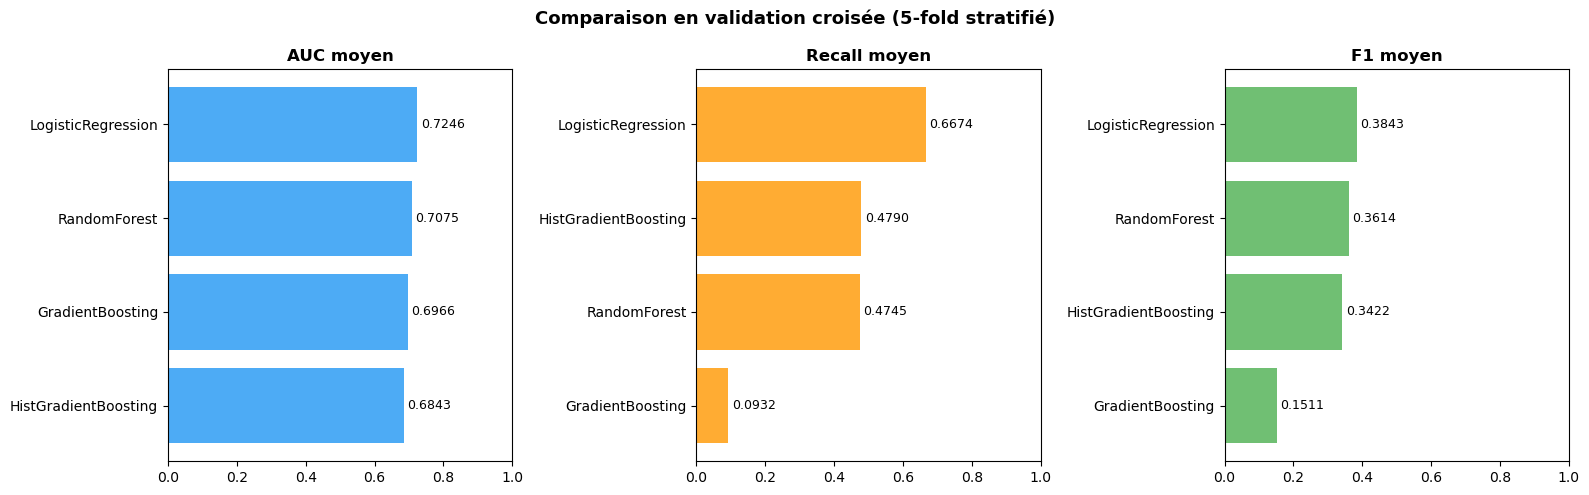

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["AUC moyen", "Recall moyen", "F1 moyen"]
colors  = ["#2196F3", "#FF9800", "#4CAF50"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    cv_df_sorted = cv_df.sort_values(metric, ascending=True)
    axes[i].barh(cv_df_sorted["Model"], cv_df_sorted[metric], color=color, alpha=0.8)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_xlim(0, 1)
    for j, v in enumerate(cv_df_sorted[metric]):
        axes[i].text(v + 0.01, j, f"{v:.4f}", va='center', fontsize=9)

plt.suptitle("Comparaison en validation croisée (5-fold stratifié)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

4. Optimisation par recherche sur grille :

* Sélection du meilleur modèle et optimisation des hyperparamètres.

Le modèle retenant le meilleur AUC moyen en validation croisée est sélectionné pour l'optimisation. Le `GridSearchCV` est exécuté sur `x_train` brut — le pipeline interne gère la normalisation à chaque fold.

In [10]:
best_model_name = cv_df.iloc[0]["Model"]
print(f"Meilleur modèle en CV : {best_model_name}")

param_grids = {
    "LogisticRegression": {
        "model__C"      : [0.01, 0.1, 1, 5, 10],
        "model__penalty": ["l1", "l2"],
        "model__solver" : ["liblinear"],
    },
    "RandomForest": {
        "model__n_estimators"  : [200, 300],
        "model__max_depth"     : [6, 8, 10],
        "model__min_samples_leaf": [3, 5, 8],
    },
    "GradientBoosting": {
        "model__n_estimators" : [100, 200],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth"    : [3, 4, 5],
    },
    "HistGradientBoosting": {
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_iter"     : [200, 300],
        "model__max_depth"    : [4, 5, 6],
    }
}

grid_search = GridSearchCV(
    models[best_model_name],
    param_grids[best_model_name],
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)
grid_search.fit(x_train, y_train)

print(f"\nMeilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur AUC CV      : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Meilleur modèle en CV : LogisticRegression
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Meilleurs paramètres : {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Meilleur AUC CV      : 0.7264


5. Évaluation finale du modèle optimisé :

* Optimisation du seuil de décision.

Dans un contexte de dépistage médical, minimiser les faux négatifs (patients malades classés comme sains) est prioritaire. On cherche donc le seuil qui maximise le recall tout en maintenant un niveau de précision acceptable.
Deux seuils sont étudiés : le seuil optimal pour le F1-score et le seuil garantissant un recall d'au moins 75 %.

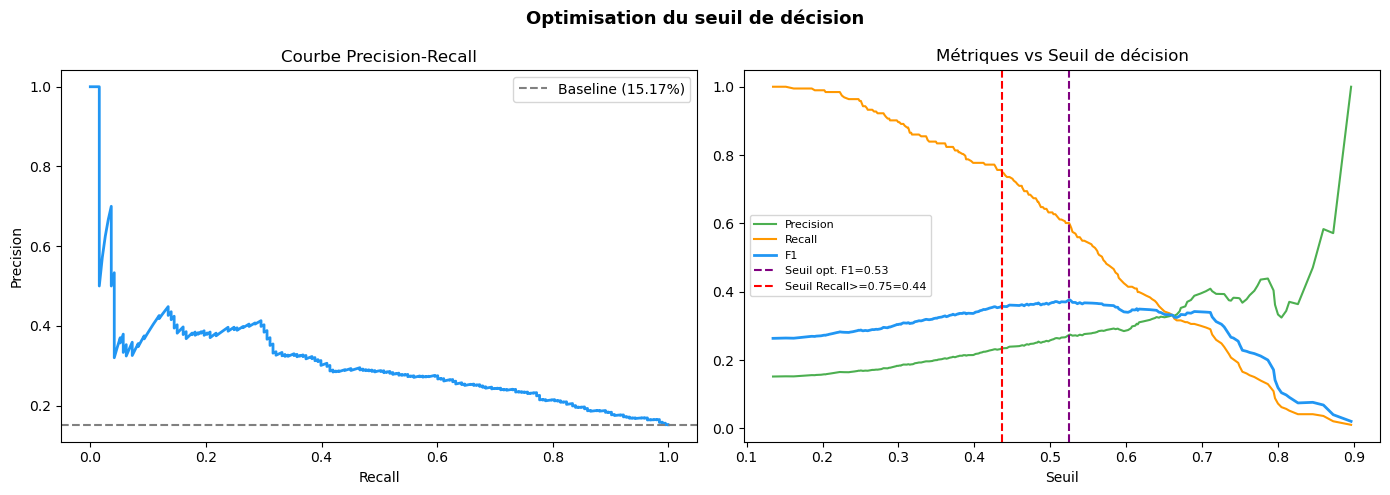

Seuil optimal F1          : 0.525
Seuil pour Recall >= 75 % : 0.436


In [11]:
y_proba_test = best_model.predict_proba(x_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_test)
f1_scores_thr = 2 * precisions * recalls / (precisions + recalls + 1e-9)

best_thr_f1 = thresholds[np.argmax(f1_scores_thr[:-1])]

recall_75_idx = np.where(recalls >= 0.75)[0]
best_thr_recall = thresholds[recall_75_idx[-1]] if len(recall_75_idx) > 0 else 0.5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recalls, precisions, color='#2196F3', lw=2)
axes[0].axhline(y_test.mean(), color='gray', linestyle='--',
                label=f'Baseline ({y_test.mean():.2%})')
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Courbe Precision-Recall")
axes[0].legend()

thr_range = thresholds[::5]
p_range   = precisions[::5]
r_range   = recalls[::5]
f1_range  = f1_scores_thr[::5]

axes[1].plot(thr_range, p_range, label='Precision', color='#4CAF50')
axes[1].plot(thr_range, r_range, label='Recall',    color='#FF9800')
axes[1].plot(thr_range, f1_range, label='F1',       color='#2196F3', lw=2)
axes[1].axvline(best_thr_f1, color='purple', linestyle='--',
                label=f'Seuil opt. F1={best_thr_f1:.2f}')
axes[1].axvline(best_thr_recall, color='red', linestyle='--',
                label=f'Seuil Recall>=0.75={best_thr_recall:.2f}')
axes[1].set_xlabel("Seuil")
axes[1].set_title("Métriques vs Seuil de décision")
axes[1].legend(fontsize=8)

plt.suptitle("Optimisation du seuil de décision", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Seuil optimal F1          : {best_thr_f1:.3f}")
print(f"Seuil pour Recall >= 75 % : {best_thr_recall:.3f}")

* Comparaison des performances selon le seuil retenu.

In [12]:
for label, thr in [("Seuil 0.50 (defaut)", 0.5),
                    (f"Seuil {best_thr_f1:.2f} (opt. F1)", best_thr_f1),
                    (f"Seuil {best_thr_recall:.2f} (opt. Recall>=75%)", best_thr_recall)]:
    y_pred_thr = (y_proba_test >= thr).astype(int)
    print(f"\n{'=' * 55}")
    print(f" {label}")
    print(f"  Recall    : {recall_score(y_test, y_pred_thr):.4f}")
    print(f"  Precision : {precision_score(y_test, y_pred_thr, zero_division=0):.4f}")
    print(f"  F1        : {f1_score(y_test, y_pred_thr):.4f}")
    print(f"  Fbeta(2)  : {fbeta_score(y_test, y_pred_thr, beta=2):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba_test):.4f}")


 Seuil 0.50 (defaut)
  Recall    : 0.6321
  Precision : 0.2579
  F1        : 0.3664
  Fbeta(2)  : 0.4900
  ROC-AUC   : 0.7033

 Seuil 0.53 (opt. F1)
  Recall    : 0.6010
  Precision : 0.2749
  F1        : 0.3772
  Fbeta(2)  : 0.4858
  ROC-AUC   : 0.7033

 Seuil 0.44 (opt. Recall>=75%)
  Recall    : 0.7513
  Precision : 0.2342
  F1        : 0.3571
  Fbeta(2)  : 0.5212
  ROC-AUC   : 0.7033


* Matrice de confusion et courbe ROC (seuil orienté recall).

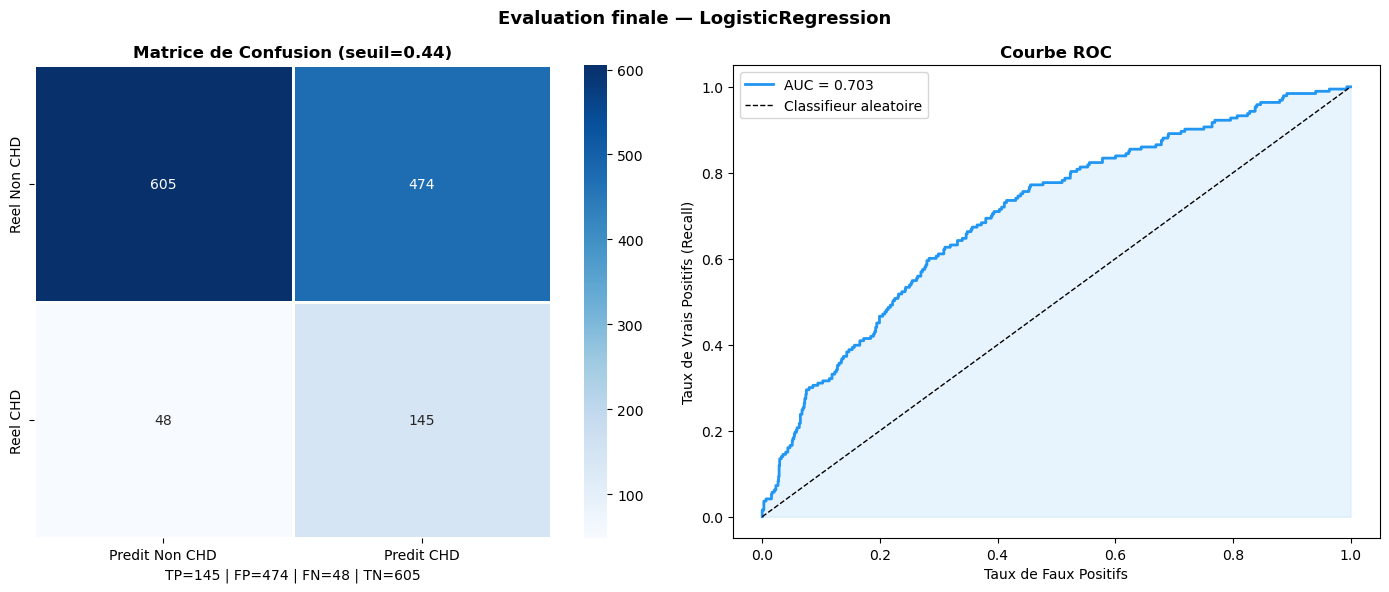


Classification Report :
              precision    recall  f1-score   support

     Non CHD       0.93      0.56      0.70      1079
         CHD       0.23      0.75      0.36       193

    accuracy                           0.59      1272
   macro avg       0.58      0.66      0.53      1272
weighted avg       0.82      0.59      0.65      1272



In [13]:
y_pred_final = (y_proba_test >= best_thr_recall).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predit Non CHD', 'Predit CHD'],
            yticklabels=['Reel Non CHD', 'Reel CHD'], linewidths=1)
axes[0].set_title(f"Matrice de Confusion (seuil={best_thr_recall:.2f})", fontweight='bold')

tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(f"TP={tp} | FP={fp} | FN={fn} | TN={tn}")

fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc = roc_auc_score(y_test, y_proba_test)
axes[1].plot(fpr, tpr, color='#2196F3', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Classifieur aleatoire')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Taux de Vrais Positifs (Recall)')
axes[1].set_title('Courbe ROC', fontweight='bold')
axes[1].legend()

plt.suptitle(f"Evaluation finale — {best_model_name}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report :")
print(classification_report(y_test, y_pred_final, target_names=['Non CHD', 'CHD']))

* Importance des features du modèle optimisé.

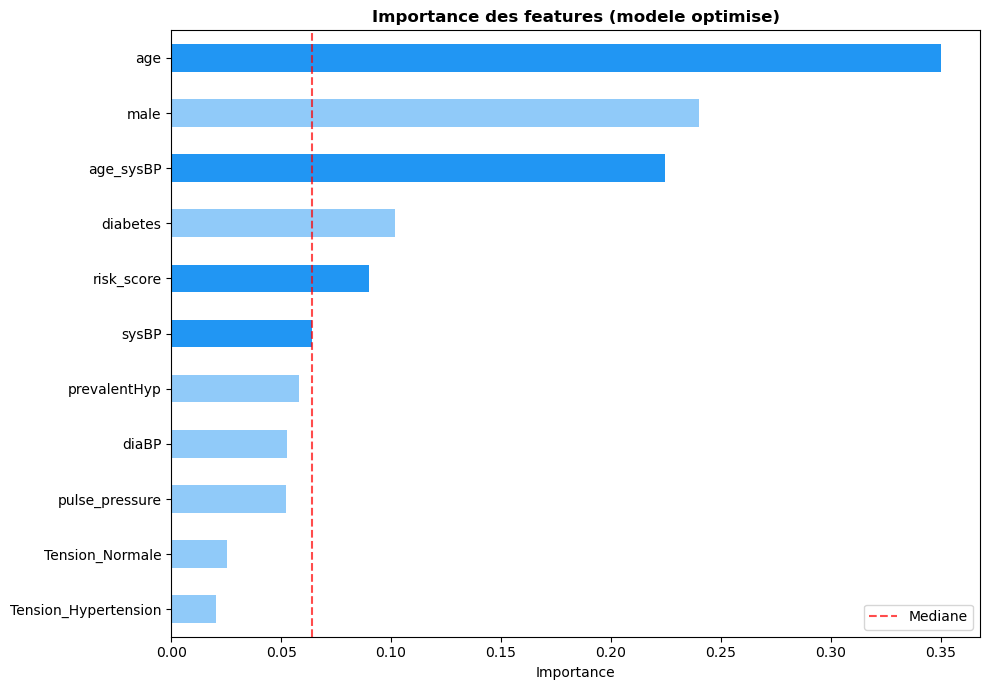

Top 5 features :
age           0.350429
male          0.239994
age_sysBP     0.224715
diabetes      0.101938
risk_score    0.089758
dtype: float64


In [14]:
model_obj = best_model.named_steps['model']

fig, ax = plt.subplots(figsize=(10, 7))

if hasattr(model_obj, 'feature_importances_'):
    importances = model_obj.feature_importances_
    feat_names  = feature.columns
elif hasattr(model_obj, 'coef_'):
    importances = np.abs(model_obj.coef_[0])
    feat_names  = feature.columns
else:
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(
        best_model, x_test, y_test,
        n_repeats=20, scoring='roc_auc',
        random_state=42, n_jobs=-1
    )
    importances = perm.importances_mean
    feat_names  = feature.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=True)
colors = ['#2196F3' if 'risk' in c or 'age' in c or 'sysBP' in c else '#90CAF9'
          for c in feat_imp.index]

feat_imp.plot(kind='barh', ax=ax, color=colors)
ax.axvline(feat_imp.median(), color='red', linestyle='--', alpha=0.7, label='Mediane')
ax.set_title("Importance des features (modele optimise)", fontweight='bold')
ax.set_xlabel("Importance")
ax.legend()
plt.tight_layout()
plt.show()

print("Top 5 features :")
print(feat_imp.sort_values(ascending=False).head(5))

* Sauvegarde du modèle final.

Le pipeline complet est sauvegardé. Il contient la normalisation et le modèle. Il suffit de charger ce fichier pour effectuer des prédictions sur de nouvelles données, sans avoir à appliquer de normalisation séparée.

In [15]:
joblib.dump(best_model, "../outputs/best_model.pkl")

['../outputs/best_model.pkl']